In [ ]:
import hoomd
import gsd.hoomd 
from hoomd import md

import numpy as np

import matplotlib.pyplot as plt

In [1]:
box_length = 1000
radiusN = 105

hoomd.context.initialize("--mode=cpu")

HOOMD-blue 2.9.3 DOUBLE HPMC_MIXED TBB SSE SSE2 SSE3 
Compiled: 01/11/2021
Copyright (c) 2009-2019 The Regents of the University of Michigan.
-----
You are using HOOMD-blue. Please cite the following:
* J A Anderson, J Glaser, and S C Glotzer. "HOOMD-blue: A Python package for
  high-performance molecular dynamics and hard particle Monte Carlo
  simulations", Computational Materials Science 173 (2020) 109363
-----
HOOMD-blue is running on the CPU


In [2]:
snapshot = hoomd.data.make_snapshot(
    N=1, box=hoomd.data.boxdim(L=box_length, dimensions=3), 
    particle_types=['N'], bond_types=[], angle_types=[], 
    dihedral_types=[], improper_types=[], pair_types=[], 
    dtype='float')

system = hoomd.init.read_snapshot(snapshot)

notice(2): Group "all" created containing 1 particles


In [3]:
upper_wall_x = hoomd.md.wall.plane(origin=(box_length/2, 0, 0), normal=(-1, 0, 0), inside=True)
lower_wall_x = hoomd.md.wall.plane(origin=(-box_length/2, 0, 0), normal=(1, 0, 0), inside=True)
upper_wall_y = hoomd.md.wall.plane(origin=(0, box_length/2, 0), normal=(0, -1, 0), inside=True)
lower_wall_y = hoomd.md.wall.plane(origin=(0, -box_length/2, 0), normal=(0, 1, 0), inside=True)
upper_wall_z = hoomd.md.wall.plane(origin=(0, 0, box_length/2), normal=(0, 0, -1), inside=True)
lower_wall_z = hoomd.md.wall.plane(origin=(0, 0, -box_length/2), normal=(0, 0, 1), inside=True)

wall_group = hoomd.md.wall.group(upper_wall_x, lower_wall_x, 
                                 upper_wall_y, lower_wall_y, 
                                 upper_wall_z, lower_wall_z)
wall_force = hoomd.md.wall.slj(wall_group, r_cut=radiusN*(2.0**(1.0/6.0)))
wall_force.force_coeff.set('N', epsilon=1, sigma=radiusN, alpha=0,
                           r_cut=radiusN*(2.0**(1.0/6.0)))

notice(2): Notice: slj set d_max=1.0


In [4]:
md.integrate.mode_standard(dt=0.005)
langevin = md.integrate.langevin(group=hoomd.group.all(), kT=1, seed=1)
langevin.set_gamma("N", 0.001)
log = hoomd.analyze.log(filename=None,
                        quantities=["potential_energy"],
                        period=1,
                        overwrite=True,
                        phase=-1)

notice(2): integrate.langevin/bd is using specified gamma values


In [17]:
energies = []
x_positions = [i/100*box_length  for i in range(-99, 100)]

In [18]:
for x_position in x_positions:
    system.particles[0].position = [x_position, 0, 0]
    hoomd.run(0)
    energies.append(log.query("potential_energy"))
    hoomd.run(1)

*Warning*: compute.thermo: given a group with 0 degrees of freedom.
            overriding ndof=1 to avoid divide by 0 errors


** starting run **
Time 00:05:10 | Step 0 / 0 | TPS 0 | ETA -2562047:-47:-16
Average TPS: 0
---------
** run complete **


*Warning*: compute.thermo: given a group with 0 degrees of freedom.
            overriding ndof=1 to avoid divide by 0 errors


** starting run **
Time 00:05:10 | Step 1 / 1 | TPS 4.59724 | ETA 00:00:00
Average TPS: 4.57649
---------
** run complete **


*Warning*: compute.thermo: given a group with 0 degrees of freedom.
            overriding ndof=1 to avoid divide by 0 errors


...

** starting run **
Time 00:05:12 | Step 198 / 198 | TPS 166667 | ETA 00:00:00
Average TPS: 6134.97
---------
** run complete **


*Warning*: compute.thermo: given a group with 0 degrees of freedom.
            overriding ndof=1 to avoid divide by 0 errors


** starting run **
Time 00:05:12 | Step 198 / 198 | TPS 0 | ETA -2562047:-47:-16
Average TPS: 0
---------
** run complete **


*Warning*: compute.thermo: given a group with 0 degrees of freedom.
            overriding ndof=1 to avoid divide by 0 errors


** starting run **
Time 00:05:12 | Step 199 / 199 | TPS 166667 | ETA 00:00:00
Average TPS: 6134.97
---------
** run complete **


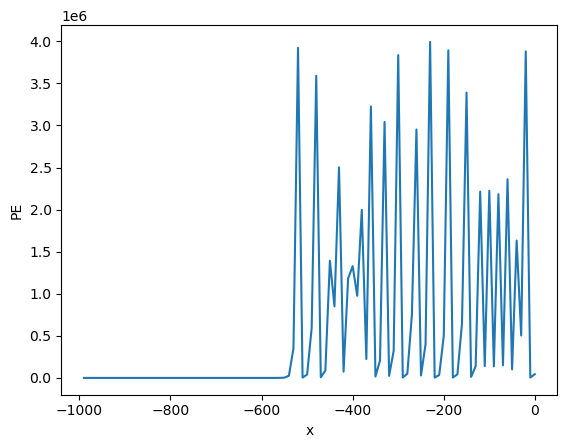

In [29]:
plt.plot(x_positions[0:100],energies[0:100])
plt.xlabel("x")
plt.ylabel("PE")
plt.show()

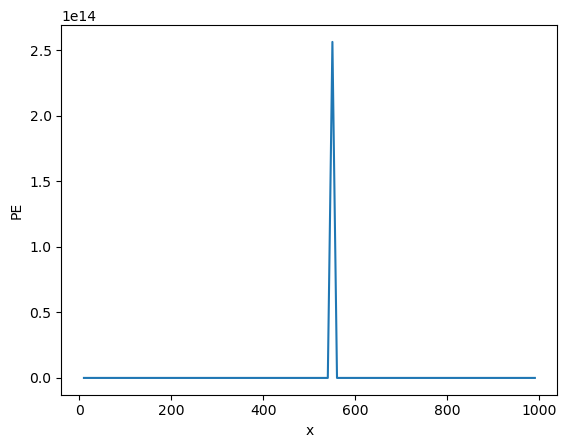

In [30]:
plt.plot(x_positions[100:],energies[100:])
plt.xlabel("x")
plt.ylabel("PE")
plt.show()